## Configuracion y Entorno

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Cargar los datos desde la carpeta de procesados
df = pd.read_csv('customer-segmentation-analysis\data\processed\df_clean.csv')
df_scaled = pd.read_csv('customer-segmentation-analysis\data\processed\df_scaled.csv')


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alvar\AppData\Local\Temp\ipykernel_77328\3683189576.py:9: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('customer-segmentation-analysis\data\processed\df_clean.csv')
C:\Users\alvar\AppData\Local\Temp\ipykernel_77328\3683189576.py:10: SyntaxWarning: invalid escape sequence '\d'
  df_scaled = pd.read_csv('customer-segmentation-analysis\data\processed\df_scaled.csv')


## Desarrollo del Modelo


In [2]:
# 1. Configuración del Modelo
# Usamos init='k-means++' para que la ubicación inicial de los centros sea inteligente y converja más rápido.
# Fijamos un random_state para que los resultados sean exactamente los mismos.
# El número de clusters (n_clusters) lo definimos en 3, por la interpretacion que tuvimos del dataset.
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

# 2. Entrenamiento del Modelo
kmeans.fit(df_scaled)

# 3. Asignación de Etiquetas
# Extraemos el número de grupo (0, 1 o 2) y se lo pegamos a nuestra tabla ORIGINAL (no a la estandarizada).
# Esto con el objetivo de poder interpreatr los resultados de manera más sencilla.
df['Cluster'] = kmeans.labels_

# Vista rápida de cuántos clientes hay en cada segmento
print("Distribución de Clientes por Segmento:")
print(df['Cluster'].value_counts())

Distribución de Clientes por Segmento:
Cluster
2    1405
1     820
0       4
Name: count, dtype: int64


In [3]:
# 4. Interpretación Financiera de los Segmentos
perfil_clusters = df.groupby('Cluster').agg({
    'Total_Spent': 'mean',        # Cuánto gastan en promedio
    'Income': 'mean',             # Ingresos promedio
    'Age': 'mean',                # Edad promedio
    'Total_Children': 'mean',     # Número de dependientes promedio
    'NumDealsPurchases': 'mean'   # Promedio de compras con descuento (sensibilidad al precio)
}).round(2)

print("\n--- Perfil Financiero y Demográfico de cada Clúster ---")
print(perfil_clusters)


--- Perfil Financiero y Demográfico de cada Clúster ---
         Total_Spent    Income    Age  Total_Children  NumDealsPurchases
Cluster                                                                 
0             767.00  51705.00  51.25            0.75               1.50
1            1281.41  72094.82  58.73            0.46               1.90
2             210.62  39669.26  56.18            1.24               2.57


## Analisis de Componentes
Ahora lo que buscamos con el PCA es visualizar nuestros clusteres y evaluar la calidad del algoritmo y simplificar la interpretacion.

In [4]:
# 1. Configurar PCA para reducir todo a solo 2 dimensiones
pca = PCA(n_components=2)

# 2. Aplicar la transformación a nuestra matriz estandarizada
componentes_principales = pca.fit_transform(df_scaled)

# 3. Guardar los resultados en una nueva tabla temporal para graficar
df_pca = pd.DataFrame(data=componentes_principales, columns=['PC1', 'PC2'])

# 4. Pegarle la etiqueta de los clústeres que generó K-Means
df_pca['Cluster'] = df['Cluster']

df_pca.head()

,PC1,PC2,Cluster
0,4.402572,-0.944412,1
1,-2.704802,-0.584910,2
2,1.650399,-1.172247,1
3,-2.527720,-1.592840,2
4,-0.277292,0.262641,2


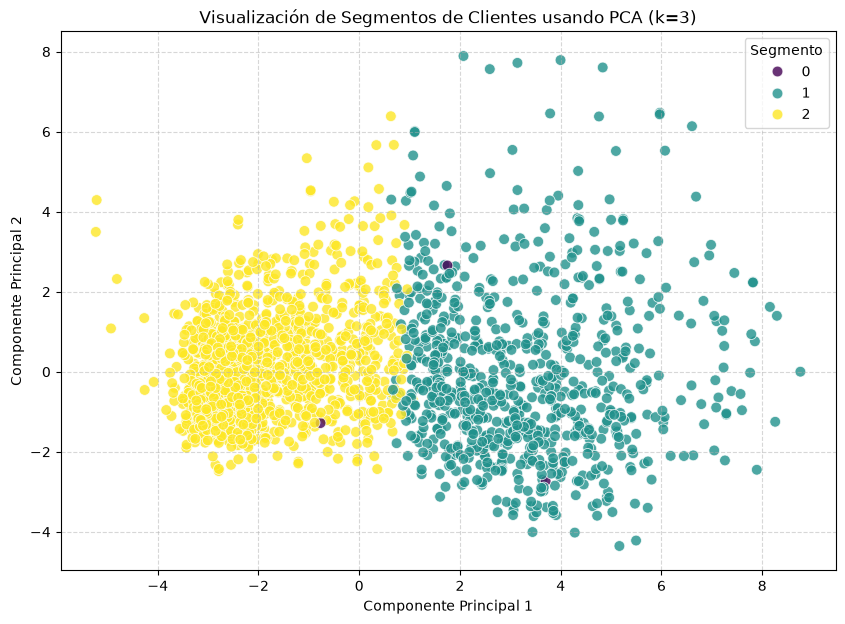

In [5]:
plt.figure(figsize=(10, 7))

# Crear el gráfico de dispersión (scatter plot)
# Usamos PC1 en el eje X, PC2 en el eje Y, y el 'hue' pinta los puntos según su clúster
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=60, alpha=0.8)

plt.title('Visualización de Segmentos de Clientes usando PCA (k=3)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Formatear la leyenda para que se vea profesional
plt.legend(title='Segmento')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Investigacion e Interpretacion
Se observa que en cuanto a el cluster 1 y 2 hay una diferencia clara, el algortimo funciono correctamente, pero en cuanto a el grupo 0, es visiblemente un problema, esto debido a que algunos valores atipicos pasaron el proceso de limpieza.

Lo que se hara es hacer una investigacion de estos valores para determinar que hace que este grupo este tan separado.


In [6]:
# Agrupamos por clúster y calculamos promedios y conteos
analisis_vip = df.groupby('Cluster').agg({
    'Total_Spent': ['mean', 'count'],  # Promedio de gasto y número total de clientes
    'Income': 'mean',                  # Nivel de ingresos
    'NumCatalogPurchases': 'mean',     # Compras por catálogo (suele ser el canal más caro)
    'NumWebPurchases': 'mean',         # Compras en la web
    'NumStorePurchases': 'mean',       # Compras físicas en tienda
    'Age': 'mean'                      # Edad promedio
}).round(1) # Redondeamos a 1 decimal para leerlo más fácil

print("--- Análisis de Perfiles de Clientes ---")
print(analisis_vip)

--- Análisis de Perfiles de Clientes ---
        Total_Spent         Income NumCatalogPurchases NumWebPurchases  \
               mean count     mean                mean            mean   
Cluster                                                                  
0             767.0     4  51705.0                 2.2             2.5   
1            1281.4   820  72094.8                 5.5             5.8   
2             210.6  1405  39669.3                 1.0             3.1   

        NumStorePurchases   Age  
                     mean  mean  
Cluster                          
0                     5.8  51.2  
1                     8.6  58.7  
2                     4.2  56.2  


Encontramos que el cluster 0 con 4 personas no aporta un valor real a nuestro algoritmo ni un valor predictivo o comercial. 
La solucion decisida es purgar el ruido que generan estos 4 clientes y eliminarlos del dataset.

In [7]:

# 1. Identificar el ruido (los 4 clientes) 
clientes_ruido = df[df['Cluster'] == 0].index

# 2. Eliminarlos de nuestra tabla original
df = df.drop(clientes_ruido)

# 3. Borrar la columna 'Cluster' vieja para empezar limpios
df = df.drop(columns=['Cluster'])

# 4. Volver a preparar la matriz matemática 
df_encoded = pd.get_dummies(df, drop_first=True)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

# 5. Volver a entrenar el modelo con los datos purgados
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# 6. Calcular los nuevos promedios
nuevos_perfiles = df.groupby('Cluster').agg({
    'Total_Spent': ['mean', 'count'],
    'Income': 'mean',
    'NumDealsPurchases': 'mean'
}).round(1)

print("--- Nuevos Perfiles (Ruido Eliminado) ---")
print(nuevos_perfiles)

--- Nuevos Perfiles (Ruido Eliminado) ---
        Total_Spent         Income NumDealsPurchases
               mean count     mean              mean
Cluster                                             
0             194.2     4  34707.0               2.8
1             605.6  2216  51651.4               2.3
2             769.0     5  50931.2               2.4


### El nuevo Problema y la solucion
Podemos observar que lo anteriormente realizado no resultado e incluso nos da resultados desastrosos y peores que los primeros, ya que tenemos un cluster masivo y dos aislados, por ahora tomaremos un enfoque distinto centrado en la optimizacion.

Aplicaremos el modelo llamado RFM para darle al modelo restricciones en base al comportamiento comercial de los clientes, forzandolo a tomar exclusivamente variables continuas de impacto financiero (Ingresos, Gasto total, edad, hijos y compras con descuento). De esta manera quitaremos el ruido de algunos datos que quiza no representen un valor real en el agrupamiento de los clientes.

In [8]:
# 1. Feature Selection: Nos quedamos SOLO con las variables de impacto comercial
columnas_clave = ['Total_Spent', 'Income', 'Age', 'Total_Children', 'NumDealsPurchases']
df_core = df[columnas_clave]

# 2. Estandarizamos exclusivamente esta matriz reducida
scaler = StandardScaler()
df_core_scaled = pd.DataFrame(scaler.fit_transform(df_core), columns=df_core.columns)

# 3. Re-entrenamos el modelo asegurando la estructura de k=3
kmeans_opt = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans_opt.fit_predict(df_core_scaled)

# 4. Evaluamos la nueva distribución
perfiles_optimizados = df.groupby('Cluster').agg({
    'Total_Spent': ['mean', 'count'],
    'Income': 'mean',
    'Age': 'mean'
}).round(1)

print("--- Perfiles Optimizados (Enfoque Financiero) ---")
print(perfiles_optimizados)

--- Perfiles Optimizados (Enfoque Financiero) ---
        Total_Spent         Income   Age
               mean count     mean  mean
Cluster                                 
0             445.5   689  49951.3  63.2
1             128.7   816  33448.2  50.6
2            1298.2   720  73809.6  58.7


### Grafica de Perfil Financiero

C:\Users\alvar\AppData\Local\Temp\ipykernel_77328\1488798146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Total_Spent', data=df, palette='viridis')
C:\Users\alvar\AppData\Local\Temp\ipykernel_77328\1488798146.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Income', data=df, palette='viridis')


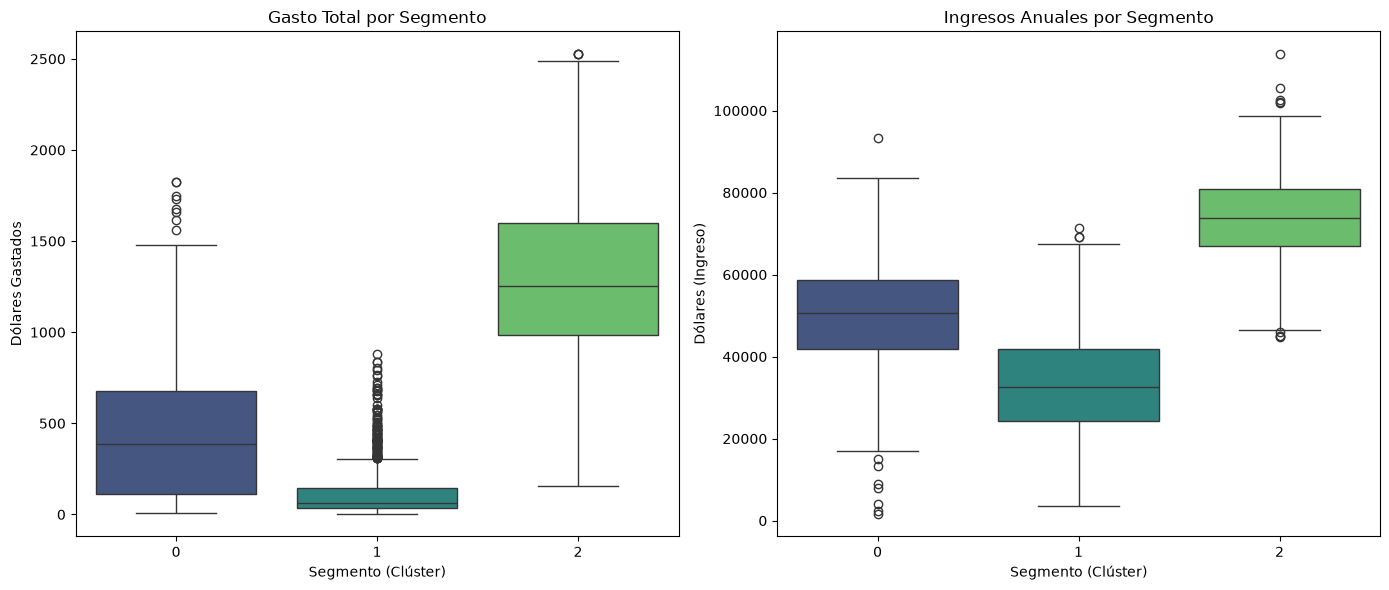

In [9]:
# Configurar el lienzo
plt.figure(figsize=(14, 6))

# Gráfica 1: Gasto Total por Clúster
plt.subplot(1, 2, 1)
sns.boxplot(x='Cluster', y='Total_Spent', data=df, palette='viridis')
plt.title('Gasto Total por Segmento')
plt.xlabel('Segmento (Clúster)')
plt.ylabel('Dólares Gastados')

# Gráfica 2: Ingresos por Clúster
plt.subplot(1, 2, 2)
sns.boxplot(x='Cluster', y='Income', data=df, palette='viridis')
plt.title('Ingresos Anuales por Segmento')
plt.xlabel('Segmento (Clúster)')
plt.ylabel('Dólares (Ingreso)')

plt.tight_layout()
plt.show()

### PCA Optimizado

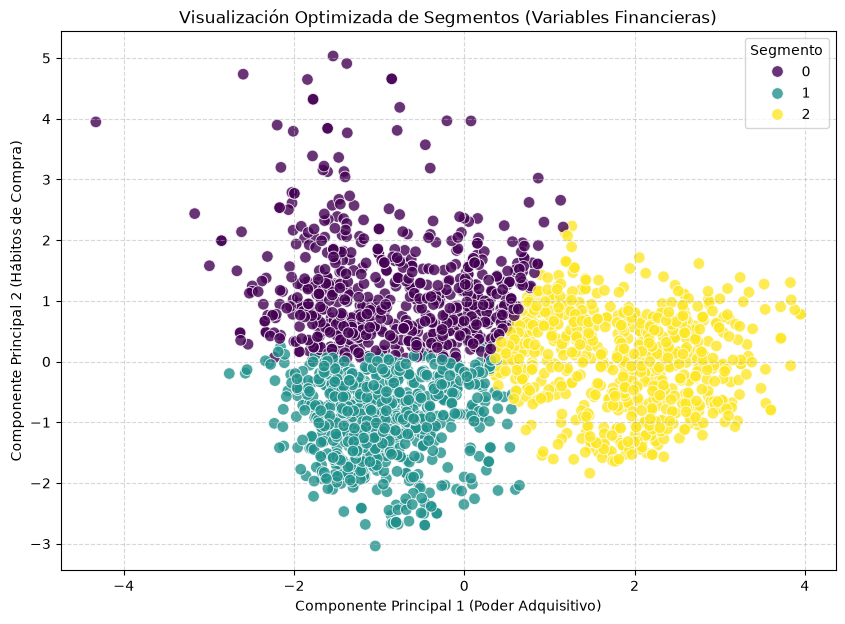

In [10]:
# 1. Aplicar PCA a la matriz purgada y optimizada
pca_opt = PCA(n_components=2)
componentes_optimizados = pca_opt.fit_transform(df_core_scaled)

# 2. Crear tabla temporal para graficar
df_pca_opt = pd.DataFrame(data=componentes_optimizados, columns=['PC1', 'PC2'])
df_pca_opt['Cluster'] = df['Cluster'].values # Le pegamos las nuevas etiquetas

# 3. Generar el gráfico
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=df_pca_opt, 
    palette='viridis', 
    s=70, 
    alpha=0.8
)

plt.title('Visualización Optimizada de Segmentos (Variables Financieras)')
plt.xlabel('Componente Principal 1 (Poder Adquisitivo)')
plt.ylabel('Componente Principal 2 (Hábitos de Compra)')
plt.legend(title='Segmento')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()